In [67]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated
from pydantic import Field, BaseModel
import operator

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(
    model = 'llama-3.3-70b-versatile'
)

In [40]:
class evaluation_schema(BaseModel):
    feedback: str = Field(description='Detailed feedback of the essay')
    score: int = Field(description='give score out of 10', ge=0, le=10)

In [41]:
structured_model = model.with_structured_output(evaluation_schema)

In [7]:
essay = 'Pakistan’s political landscape has been defined by perpetual turbulence, characterized by a delicate dance between civilian governance and a powerful military establishment. Since gaining independence in 1947, the South Asian nation has struggled to achieve long-term democratic consolidation. No democratically elected prime minister in Pakistan’s history has ever completed a full five-year term. Today, Pakistan exists in a state of political paradox: the country is managing institutional and fiscal stabilization reforms while grappling with intense polarization, judicial battles, and public distrust.The Hybrid Structure and Hyper-PolarizationThe modern political architecture of Pakistan functions as a hybrid democracy. While general elections are held to form the National Assembly, the military establishment continues to hold significant sway over foreign policy, internal security, and macroeconomic directives.The political sphere is deeply polarized, split between the ruling coalition—led by the Pakistan Muslim League-Nawaz (PML-N) and the Pakistan Peoples Party (PPP)—and the opposition, primarily anchored by Imran Khan’s Pakistan Tehreek-e-Insaf (PTI). Despite the imprisonment of high-profile leadership figures, PTI retains a highly vocal and digitally active support base. This deep-seated division has turned governance into a battleground of political survival rather than policy implementation, where constitutional contestations often eclipse parliamentary debate.The Economic Dilemma as a Political CatalystIn Pakistan, politics and economics are inextricably linked. The country’s political instability directly fuels its fiscal vulnerability, and vice versa.The IMF Dependency: Pakistan relies heavily on external bailouts, including a massive $7 billion International Monetary Fund (IMF) program, to avoid sovereign default.Structural Bottlenecks: The government faces severe structural crises, such as a dismal tax-to-GDP ratio, stagnant export growth, and soaring cost-of-living pressures.The Public Cost: While short-term stabilization measures have marginally lowered hyper-inflation from its record peaks, the domestic population continues to struggle with high electricity tariffs, unemployment, and heavy taxation.'

In [49]:
class essay_state(TypedDict):
    essay:str
    language_feedback:str
    analysis_feedback:str
    clarity_feedback:str
    overall_feedback:str
    individual_scores: Annotated[list[int], operator.add]
    avg_score:int

In [53]:
def evaluate_language(state: essay_state):
    prompt = f"Evaluate the language of the following essay and provide a feedback and give a score out of 10, {state['essay']}"
    output = structured_model.invoke(prompt)

    return {'language_feedback': output.feedback, 'individual_scores':[output.score]}

In [54]:
def evaluate_analysis(state:essay_state):
    prompt = f"Evaluate the analysis of th efollowing essay and  provide a feedback and give a score out of 10, {state['essay']}"
    output = structured_model.invoke(prompt)

    return {'analysis_feedback':output.feedback, 'individual_scores':[output.score]}

In [55]:
def evaluate_clarity(state:essay_state):
    prompt = f"Evaluate the clarity of the following essay and provide a feedback and give a score out of 10, {state['essay']}"
    output = structured_model.invoke(prompt)

    return {'clarity_feedback':output.feedback, 'individual_scores':[output.score]}

In [56]:
def overall_feedback(state:essay_state):
    prompt = f"based on the following feedbacks , give a summarized feedback, \nLanguage feedback : {state['language_feedback']}, \nanalysis_feedback : {state['analysis_feedback']}, \nClarity_feedback : {state['clarity_feedback']}"
    output = structured_model.invoke(prompt)
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'overall_feedback':output.feedback, 'individual_scores':[avg_score]}

In [57]:
graph = StateGraph(essay_state)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_clarity', evaluate_clarity)
graph.add_node('overall_feedback', overall_feedback)

graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_clarity')

graph.add_edge('evaluate_language', 'overall_feedback')
graph.add_edge('evaluate_analysis', 'overall_feedback')
graph.add_edge('evaluate_clarity', 'overall_feedback')

graph.add_edge('overall_feedback', END)

workflow = graph.compile()

In [65]:
initial_state = {'essay':essay}
workflow.invoke(initial_state)

{'essay': 'Pakistan’s political landscape has been defined by perpetual turbulence, characterized by a delicate dance between civilian governance and a powerful military establishment. Since gaining independence in 1947, the South Asian nation has struggled to achieve long-term democratic consolidation. No democratically elected prime minister in Pakistan’s history has ever completed a full five-year term. Today, Pakistan exists in a state of political paradox: the country is managing institutional and fiscal stabilization reforms while grappling with intense polarization, judicial battles, and public distrust.The Hybrid Structure and Hyper-PolarizationThe modern political architecture of Pakistan functions as a hybrid democracy. While general elections are held to form the National Assembly, the military establishment continues to hold significant sway over foreign policy, internal security, and macroeconomic directives.The political sphere is deeply polarized, split between the rulin

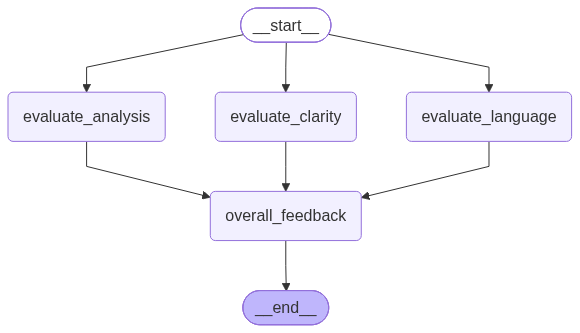

In [66]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())